In [113]:
import yaml, torch, sys
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import torch.nn.functional as F
import random as random
import re
import torch, json, random, os
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch.nn as nn
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader, TensorDataset
import sys
import os
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

from types import SimpleNamespace
#add more packages here
sys.path.insert(0, '../../')
from utils.train_model import run_experiment, set_seed, get_device

In [46]:
import importlib
import utils.train_model
importlib.reload(utils.train_model)
from utils.train_model import run_experiment, set_seed, get_device

In [114]:

sys.path.insert(0, '../../')
from utils.train_model import set_seed, get_device

with open('../../configs/defaults.yaml') as f:
    config = yaml.safe_load(f)

with open('../../configs/EX_01.yaml') as f:
    config.update(yaml.safe_load(f))
    
    

def to_namespace(d):
    if isinstance(d, dict):
        return SimpleNamespace(**{k: to_namespace(v) for k, v in d.items()})
    return d

config = to_namespace(config)

set_seed(config.seed)
device = get_device()

RAW_DIR  = Path(config.raw_dir)
GRAD_DIR = Path(config.grad_dir)


data_dir = Path("./EX_01/Raw/")



[device] using cpu


# Context.

This is the first experiment of the first epic, whose purpose is to establish a baseline. The purpose of EX_01 is to establish the most minimum baseline version of this paper. It is expected that performance will be very poor, but we want to validate and be sure that what we wish to do is doable, before we start optimizing.

First, what we are learning mathematically is a optimal mask over a glyph, which both maximally reduces the probabilty of recognition before the application of a blur, and maximizes the probability of recognition after the application of this blur. For the purposes of this paper, we restrict the possible blurs to blurs that may be modeled by a human hand holding a camera of relatively standard quality - the vaugeness of this description allows for a sufficiently robust set of possible blurs. 

# Hypothesis

Thus, our formal hypothesis is as follows:

A 3-layer "standard" CNN can achieve a higher combined score than a manual approach. Here, "combined score" can be represented by the following mathematical function:

$\Delta-VIS(b, i) = -\alpha * p(x) + \beta * p(y)$

Where $x$ is confidence prior to the blur, and $y$ is posterior, and a $(b, i)$ pair is a background and hidden image pair. 

# Implementation 

$p(x)$ is measured by a simple classifer trained on the MNIST dataset. It consists of two convolutional layers and three linear layers, and achieves an accuracy of 99% after 10 epochs. All layer weights and frozen and will be used as is throughout all experiments unless mentioned otherwise. $p$ is the confidence of the model that the given image is depicting the correct number. 

The "standard CNN" will be a classifier with a single convolutional "block", consisting of a 

# Data

Each background is a sythentically created gradient between two random colors, in a 28x28p image. Each image will be a randomly selected item of the MNIST dataset.

For right now, we're just going to plop the mnist image (in the code called "i" or "image") over the gradient background (in the code called "b" or "background"), forming a 4-channel image (called "c" or "comp" in the code). Future experiments should expand on this by learning other combinations. 

# Notes

It is expected that some $(b, i)$ pairs will work better than others, and we hope we will have sufficient time for the project to also build a classifer to determine this, or else incorporate it in our given model. A useful extension, which is unlikely to be completed in our work, is to automatically build the best possible background. 

# Code

## MNIST Classifer
Here we build the function m_classify, and ensure it works correctly:

In [115]:
class LeNet3channel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1   = nn.Linear(16*5*5, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)

    def forward(self, x):
        x = F.avg_pool2d(F.relu(self.conv1(x)), 2)
        x = F.avg_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.size(0), -1)
        return self.fc3(F.relu(self.fc2(F.relu(self.fc1(x)))))

def alpha_combine(b, i):
    alpha = i.expand_as(b)
    comp = alpha * i.expand_as(b) + (1 - alpha) * b
    return comp
    
def additive_combine(b, i):
    comp = b + i.expand_as(b) #[3, 28, 28]
    return comp


class ex01b(Dataset):
    def __init__(self, batch_size, transform=None):
        self.pairings = pd.read_csv(Path(config.csv_path))
        self.gradients_dir = Path(config.grad_dir)
        self.transform = transform if transform is not None else transforms.ToTensor()
        self.mnist     = datasets.MNIST('../../data/', train=True, download=False,
                                        transform=transforms.ToTensor())

    def __len__(self):
        return len(self.pairings)

    def __getitem__(self, idx):
        ann = self.pairings.iloc[idx]
        if not isinstance(ann["gradient_path"], str):
            raise Exception ("huhhh")
        b_img_path =  ann["gradient_path"]
        b = self.transform(Image.open(b_img_path).convert("RGB")) 
        i, lab = self.mnist[int(ann["mnist_idx"])]

        if config.combination_type == "alpha":
            comp = alpha_combine(b, i)
        else:
            comp = additive_combine(b, i)
        return comp.clamp(0, 1), lab
    
    def __getitems__(self, indices):
        return [self[i] for i in indices]

ex01b_trainset = ex01b(batch_size = config.batch_size)
ex01b_trainloader = DataLoader(ex01b_trainset, batch_size=config.batch_size, shuffle=True)
ex01b_valloader = DataLoader(ex01b_trainset, batch_size=config.batch_size, shuffle=True)


In [116]:
def ex01b_loss_fn(batch, model, mode="train", **kwargs):
    imgs, labels = batch
    logits = model(imgs)
    loss = nn.CrossEntropyLoss()(logits, labels)

    if mode == "val":
        acc = (logits.argmax(1) == labels).float().mean().item()
        return {"val_loss": loss.item(), "val_acc": acc}
    return loss


# ── RUN ───────────────────────────────────────────────────────────────────────
ex01b_info = {
    "exp_id":      "EX_01b",
    "epochs":      3,
    "log_to":      "both", #"file" if you dont want wandb 
    "weights_dir": "Model/B",
    "log_dir":     "logs/B",
    "seed":        42,
    "notes": "a 3 channel mnist classifer. comb_type shouldn't matter"
}

b_model = LeNet3channel()
optimizer = torch.optim.Adam(b_model.parameters(), lr=config.lr)

if True: #change to retrain
    b_model = LeNet3channel().to(device)
    b_model.load_state_dict(torch.load('Model/B/EX_01b_final.pt', map_location=device, weights_only=True))
    b_model.eval()

else:
    run_experiment(
        model=b_model,
        optimizer=optimizer,
        loss_fn=ex01b_loss_fn,
        train_loader=ex01b_trainloader,
        val_loader=ex01b_valloader,
        config=ex01b_info,
        log_to=ex01b_info["log_to"],
    )
    
# returns conf, predicted
def m_classify_3d_with_conf(image, correct):
    if image.shape[1] != 3:
        raise Exception(f"expected a 3 dim image, got a image of shape {image.shape}")
    # with torch.no_grad():
    logits = b_model(image)
    preds = torch.softmax(logits, dim=1)
    max_pred = torch.argmax(logits, dim=1)
    return preds[torch.arange(preds.shape[0]), correct], max_pred

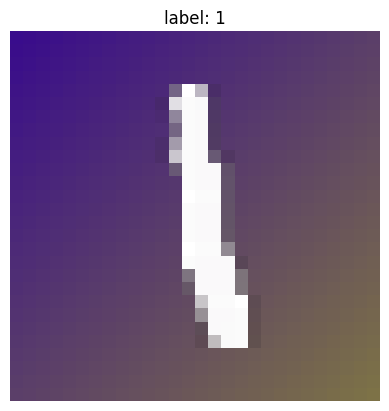

true: 1, predicted: 1, conf: 1.0000


In [44]:


idx = random.randint(0,10)
digit, label = ex01b_trainset[idx]


# show it
plt.imshow(digit.permute(1, 2, 0))
plt.title(f"label: {label}")
plt.axis("off")
plt.show()

digit = digit.unsqueeze(0).to(device)  # (1, 3, 28, 28)
conf, predicted = m_classify_3d_with_conf(digit, label)
print(f"true: {label}, predicted: {predicted.item()}, conf: {conf[0].item():.4f}")

Seems decent. Let's build the "manual" method. I personally don't know hardly anything about what a good mask would look like, so let's just use a random one. Surely almost anything intentional will be better than this. If we can't beat this, we've got serious problems on our hands.

In [121]:
#60k seems a lot for this - starting with 10k and we'll see what we get from that 
subset = torch.utils.data.Subset(ex01b_trainset, range(256*10))
ex01b_trainloader = DataLoader(subset, batch_size=config.batch_size) #for testin
ex01b_valloader = DataLoader(subset, batch_size=config.batch_size) 

In [123]:
# ── DUMMY MODEL ───────────────────────────────────────────────────────────────
# no layers — just applies a box blur and passes through
#overall pipeline is the model takes in an b and an i, learn a mask for i, loss function actually handles everything at this point.

class RandomMask(nn.Module):
    def __init__(self):
        super().__init__()
        self.p = config.variants.a.dropout_rate
    
    def forward(self, x):     
        mask          = (torch.rand_like(digit) > self.p).float()
        composite = x * mask
        return composite

def box_blur(x, kernel_size=9):
    channels = x.shape[1]
    kernel = torch.ones(channels, 1, kernel_size, kernel_size, 
                        device=x.device) / (kernel_size ** 2)
    return F.conv2d(x, kernel, padding=kernel_size//2, groups=channels)

# ── DUMMY LOSS ────────────────────────────────────────────────────────────────
def ex_01a_loss_fn(batch, model, mode="train", **kwargs):
    # b, i, label, b_idx, i_idx = batch
    comp, label = batch

    # comp = torch.cat([b, i], dim=1) #compositing by layering the i over the b
    # comp = (b + i.expand_as(b)).clamp(0, 1) #[3, 28, 28]
    masked = model(comp)
    conf_pre, pred_pre  = m_classify_3d_with_conf(masked, label)
    
    blurred = box_blur(masked)
    conf_post, pred_post = m_classify_3d_with_conf(blurred, label)
    delta_vis = (config.variants.a.alpha * conf_pre) + (config.variants.a.beta * conf_post)
    loss = (-delta_vis).mean() if delta_vis.dim() > 0 else -delta_vis
    if mode == "val":
        return {
            "val_loss":  loss.item(),
            "conf_pre":  conf_pre.mean().item(),
            "conf_post": conf_post.mean().item(),
            "delta_vis": delta_vis.mean().item()
        }
    return loss


In [124]:



# ── RUN ───────────────────────────────────────────────────────────────────────
ex01a_info = {
    "exp_id":      "EX_01a",
    "epochs":      3,
    "log_to":      "both",   # keep wandb off until pipeline is verified
    "weights_dir": "Model/A",
    "log_dir":     "logs/A",
    "seed":        42,
    "comb_type" : "alpha",
    "note": "ok all redone finally. this is a 10x batch"
}

r_model = RandomMask()
optimizer = torch.optim.Adam([torch.zeros(1, requires_grad=True)], lr=1e-3)

run_experiment(
    model=r_model,
    optimizer=optimizer,
    loss_fn=ex_01a_loss_fn,
    train_loader=ex01b_trainloader,
    val_loader=ex01b_valloader,
    config=ex01a_info,
    log_to=ex01a_info["log_to"],
)

[device] using cpu


conf_post,▇▁█
conf_pre,▅▁█
delta_vis,█▁▅
epoch,▁▅█
train_loss,█▂▁
val_loss,▁█▄
conf_post,0.20148
conf_pre,0.80831
delta_vis,-0.30341
epoch,3
train_loss,0.29008


RandomMask()

# Variation C - Simple Learned Baseline

Now we can train a simple standard model to learn the mask, which is hopefully an improvement on the random one. 

In [127]:


class baselineLearnedMask(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        mask  = self.net(x)
        return (x * mask).clamp(0, 1)

def box_blur(x, kernel_size=9):
    channels = x.shape[1]
    kernel = torch.ones(channels, 1, kernel_size, kernel_size, 
                        device=x.device) / (kernel_size ** 2)
    return F.conv2d(x, kernel, padding=kernel_size//2, groups=channels)




In [128]:

# ── RUN ───────────────────────────────────────────────────────────────────────
ex01c_info = {
    "exp_id":      "EX_01c",
    "epochs":      3,
    "log_to":      "both",
    "weights_dir": "Model/C",
    "log_dir":     "logs/C",
    "seed":        42, 
    "comb_type" : "alpha",
    "note": "and here's a 10x batch of the updated version of C"
}

model_1c = baselineLearnedMask()
optimizer = torch.optim.Adam([torch.zeros(1, requires_grad=True)], lr=1e-3)

run_experiment(
    model=model_1c,
    optimizer=optimizer,
    loss_fn=ex_01a_loss_fn,
    train_loader=ex01b_trainloader,
    val_loader=ex01b_valloader,
    config=ex01c_info,
    log_to=ex01c_info["log_to"],
)

[device] using cpu


conf_post,▁▁▁
conf_pre,▁▁▁
delta_vis,▁▁▁
epoch,▁▅█
train_loss,▁▁▁
val_loss,▁▁▁
conf_post,0.2001
conf_pre,0.94835
delta_vis,-0.37412
epoch,3
train_loss,0.37412


baselineLearnedMask(
  (net): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Sigmoid()
  )
)

# Results
Here we evaluate both models. 

In [149]:

def print_eval(df):
    all_labels    = df["label"].values
    all_pre_pred  = df["pred_pre"].values
    all_post_pred = df["pred_post"].values
    all_pre_conf  = df["conf_pre"].values
    all_post_conf = df["conf_post"].values

    print("=== PRE BLUR ===")
    print(classification_report(all_labels, all_pre_pred))
    print(f"  mean conf : {all_pre_conf.mean():.4f}")
    print(f"  max conf  : {all_pre_conf.max():.4f}")
    print(f"  min conf  : {all_pre_conf.min():.4f}")

    print("=== POST BLUR ===")
    print(classification_report(all_labels, all_post_pred))
    print(f"  mean conf : {all_post_conf.mean():.4f}")
    print(f"  max conf  : {all_post_conf.max():.4f}")
    print(f"  min conf  : {all_post_conf.min():.4f}")

    delta_conf = all_post_conf - all_pre_conf
    pre_acc    = (all_pre_pred  == all_labels).mean()
    post_acc   = (all_post_pred == all_labels).mean()
    print("=== DELTA ===")
    print(f"  acc pre       : {pre_acc:.4f}")
    print(f"  acc post      : {post_acc:.4f}")
    print(f"  acc delta     : {post_acc - pre_acc:+.4f}")
    print(f"  mean conf   : {delta_conf.mean():+.4f}")
    print(f"  max conf   : {delta_conf.max():+.4f}  (best case)")
    print(f"  min conf  : {delta_conf.min():+.4f}  (worst case)")


def run_eval(model, loader, device, variation):
    csv_path = f"Results/{variation}_preds.csv"

    if not os.path.exists(csv_path):
        model.eval()
        all_pre_pred, all_labels, all_post_pred, all_pre_conf, all_post_conf = [], [], [], [], []
        with torch.no_grad():
            for image, gold in loader:
                imgs, labels = image.to(device), gold.to(device)
                masked              = model(imgs)
                conf_pre,  pred_pre  = m_classify_3d_with_conf(masked,  labels)
                blurred             = box_blur(masked)
                conf_post, pred_post = m_classify_3d_with_conf(blurred, labels)
                all_pre_pred.extend(pred_pre.cpu().numpy())
                all_post_pred.extend(pred_post.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_pre_conf.extend(conf_pre.cpu().numpy())
                all_post_conf.extend(conf_post.cpu().numpy())

        df = pd.DataFrame({
            "label":     all_labels,
            "pred_pre":  all_pre_pred,
            "pred_post": all_post_pred,
            "conf_pre":  np.array(all_pre_conf),
            "conf_post": np.array(all_post_conf),
        })
        df.to_csv(csv_path, index=False)
    else:
        df = pd.read_csv(csv_path)

    print_eval(df)


In [147]:
c_model = baselineLearnedMask().to(device)
c_model.load_state_dict(torch.load('Model/C/EX_01c_final.pt', map_location=device))
c_model.eval()
run_eval(c_model, ex01b_trainloader, device, "C")

/scratch/slurm-8302090/ipykernel_148497/3715496139.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  c_model.load_state_dict(torch.load('Model/C/EX_01c_final.pt', map_loca

=== PRE BLUR ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       242
           1       0.98      0.99      0.99       281
           2       0.99      0.98      0.98       254
           3       0.98      0.99      0.98       248
           4       1.00      0.99      0.99       284
           5       0.99      0.98      0.98       234
           6       1.00      0.99      0.99       261
           7       0.97      0.99      0.98       281
           8       0.99      0.99      0.99       225
           9       0.99      0.97      0.98       250

    accuracy                           0.99      2560
   macro avg       0.99      0.99      0.99      2560
weighted avg       0.99      0.99      0.99      2560

  mean conf : 0.9484
  max conf  : 1.0000
  min conf  : 0.0410
=== POST BLUR ===
              precision    recall  f1-score   support

           0       0.96      0.29      0.44       242
           1       1.00      0.00 

,label,pred_pre,pred_post,conf_pre,conf_post
0,5,5,8,0.682339,0.090094
1,0,0,8,0.995384,0.157493
2,4,4,8,0.945174,0.129172
3,1,1,8,0.985862,0.095620
4,9,9,8,0.953374,0.135536
...,...,...,...,...,...
2555,8,8,8,0.954904,0.478736
2556,6,6,8,0.559000,0.056453
2557,0,0,8,0.999256,0.152811
2558,7,7,3,0.924328,0.093881


In [150]:
a_model = RandomMask().to(device)
a_model.load_state_dict(torch.load('Model/A/EX_01a_final.pt', map_location=device))
a_model.eval()
run_eval(a_model, ex01b_trainloader, device, "A")

/scratch/slurm-8302090/ipykernel_148497/3095102878.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  a_model.load_state_dict(torch.load('Model/A/EX_01a_final.pt', map_loca

=== PRE BLUR ===
              precision    recall  f1-score   support

           0       0.99      0.88      0.93       242
           1       0.92      0.86      0.89       281
           2       0.88      0.91      0.90       254
           3       0.88      0.94      0.90       248
           4       0.84      0.89      0.86       284
           5       0.88      0.92      0.90       234
           6       1.00      0.84      0.91       261
           7       0.77      0.96      0.86       281
           8       0.72      0.88      0.79       225
           9       0.92      0.60      0.72       250

    accuracy                           0.87      2560
   macro avg       0.88      0.87      0.87      2560
weighted avg       0.88      0.87      0.87      2560

  mean conf : 0.7986
  max conf  : 1.0000
  min conf  : 0.0011
=== POST BLUR ===
              precision    recall  f1-score   support

           0       0.87      0.24      0.38       242
           1       1.00      0.01 

We might also want to see the images themselves, just to ensure nothing weird is happening

=====C Model (Baseline) Pictures =========


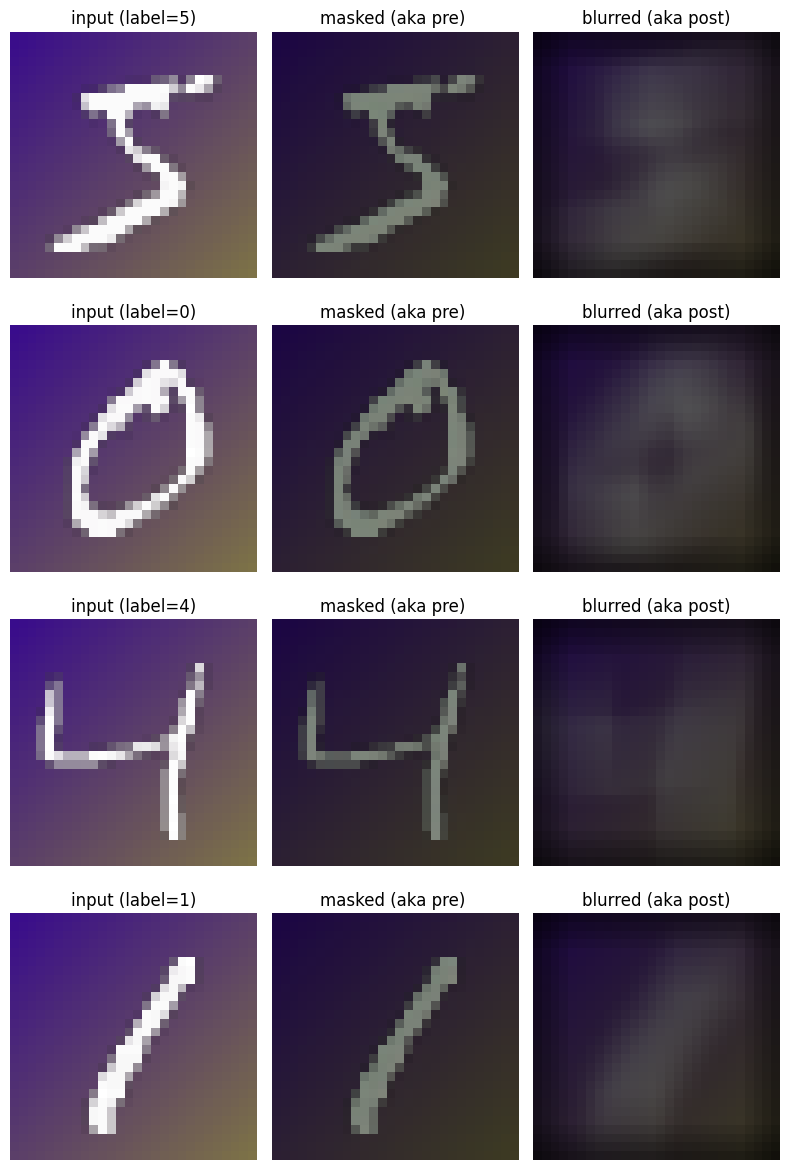

=====A Model (Random) Pictures =========


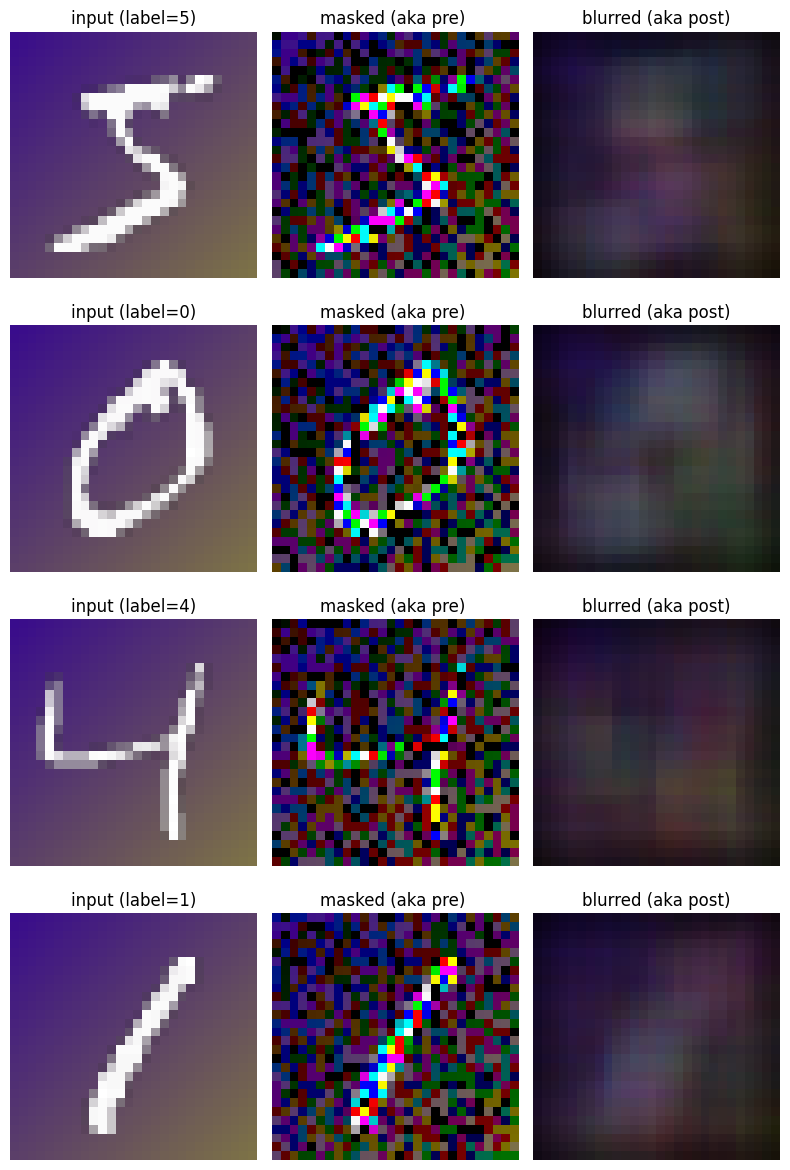

In [156]:


def show_examples(model, dataset, device, variation, n=4):
    fig, axes = plt.subplots(n, 3, figsize=(8, n*3))
    for i in range(n):
        comp, label = dataset[i]
        comp_in = comp.unsqueeze(0).to(device)
        
        with torch.no_grad():
            masked = model(comp_in)
            blurred = box_blur(masked)
        
        axes[i,0].imshow(comp.permute(1,2,0))
        axes[i,0].set_title(f"input (label={label})")
        axes[i,1].imshow(masked.squeeze(0).cpu().permute(1,2,0))
        axes[i,1].set_title("masked (aka pre) ")
        axes[i,2].imshow(blurred.squeeze(0).cpu().permute(1,2,0))
        axes[i,2].set_title("blurred (aka post)")
        for ax in axes[i]: ax.axis("off")
    
    plt.tight_layout()
    plt.savefig(f"Model/{variation}/EX_01{variation}_samples.png")
    plt.show()

print("=====C Model (Baseline) Pictures =========")
show_examples(c_model, ex01b_trainset, device, "C")
print("=====A Model (Random) Pictures =========")
show_examples(a_model, ex01b_trainset, device, "A")

# Evaluation


Overall we have a mean classification accuracy difference of -0.5754 for the random model, and -0.6793 for the baseline model, so we can fail to reject H0 - there is in fact a better way to maximize the distance between pre- and post-accuracy that is better than randomly dropping pixels. Of course, we're at around a 0.3066 accuracy in this baseline model, which is pretty abysmal, and a 0.9859 pre-accuracy which is probably even worse. Just intuitively, with the goal of a stego-type approach, we're probably more concerned about dropping the pre than we are increasing the post - that's the hard part and what we need to focus on. 

However, we have completed this experiment and have positive results so we'll try further in later ones. 


# Next steps
- Try with a steeper alpha than a beta, since we've realized we don't care about them equally
    - Try {-0.9, .1}, {-.75, 0.25}, and {-0.6, -0.4}
- Try with larger images, embedding the MNIST digit anywhere in the image. 
- Try a more descriptive mask technique:
    - visualize some masks to see what it's learning (seems it likes to blur)
    - try expanding the image - especially with a linear blur, 